# The mistakes everybody makes

### Nine ways to be confidently wrong, every one of them measured somewhere in this book

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The nine failures that produce most wrong results in applied machine learning, what each one cost when this book measured it, and which chapter to reread for the mechanism |
| **You should already know** | Nothing new. This chapter is the index to everything already measured |
| **Datasets** | UCI Dry Bean and California Housing, for the four demonstrations run here |
| **Runtime** | Under two minutes on a laptop CPU |
| **Next** | Nothing. This is the last notebook |

---

## 1. Why this list is short and specific

Lists of machine learning mistakes are usually written from memory and read like
advice. This one has a constraint: **every entry is something this book measured,
with a chapter that shows the measurement.** Anything I could not point at a
number for is not on the list.

That constraint changes the ordering. The mistakes people warn about loudest are
not the ones that cost the most, and two entries below are here because the
measurement contradicted what I expected when I ran it.

Four of them get a fresh demonstration in this notebook, because seeing a thing
happen once is worth more than reading that it can.

In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets, evaluate

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

## 2. The ledger

Every row below is transcribed from the chapter named in it, which was executed
and shipped with the figure that produced the number. The `invented` column marks
the rows where the quantity is score that did not exist: the difference between
what a flawed procedure reported and what an honest one reported on the same data.

In [2]:
LEDGER = pd.DataFrame([
    # mistake, chapter, what was measured, value, units, invented
    ("leaking a fitted step", "01-04",
     "accuracy manufactured on pure noise by selecting columns outside the loop",
     0.2550, "accuracy", True),
    ("leaking a fitted step", "01-07",
     "R squared manufactured by target encoding computed in-fold, on a noise column",
     0.2502, "R squared", True),
    ("leaking a fitted step", "01-08",
     "R squared manufactured by a KNN imputer fitted before the split",
     1.2226, "R squared", True),
    ("leaking a fitted step", "03-07",
     "F1 manufactured by oversampling before the split, logistic regression",
     0.6810, "F1", True),
    ("tuning against the test set", "01-09",
     "a grid search's own best score against nested cross-validation",
     0.0074, "accuracy", True),
    ("tuning against the test set", "01-09",
     "simulated: 500 candidates all truly worth 0.900, best one reported",
     0.0606, "accuracy", True),
    ("accuracy on unbalanced classes", "01-05",
     "margin of a real model over always predicting negative, at 1% positives",
     0.0030, "accuracy", False),
    ("accuracy on unbalanced classes", "03-07",
     "the same margin at a 1.66% positive rate",
     0.0092, "accuracy", False),
    ("importance read as causation", "12-02",
     "impurity importance handed to a column of pure noise, against 0.0276 for a real feature",
     0.0214, "MDI", False),
    ("importance read as causation", "12-02",
     "permutation importance of one feature alone, against 0.7990 for it and its twin together",
     0.2502, "R squared drop", False),
    ("no baseline", "02-01",
     "RMSE of predicting the mean, against 0.726 for linear regression",
     1.1540, "RMSE", False),
    ("one split, no interval", "01-04",
     "spread of a single 80/20 split over 200 seeds, against 0.0074 for 5-fold",
     0.0226, "accuracy sd", False),
    ("variance without the signal", "11-07",
     "noise-to-signal ratio after lowering gamma cut raw variance by more than 100x",
     71.07, "noise / signal", False),
    ("a training curve is not a policy", "07-06",
     "test accuracy at the validation-loss minimum, epoch 9, against 0.8170 at epoch 18",
     0.7963, "accuracy", False),
    ("a training curve is not a policy", "07-06",
     "accuracy reported when model.eval() is forgotten at batch size 8, true value 0.7533",
     0.6426, "accuracy", False),
], columns=["mistake", "chapter", "what was measured", "value", "units", "invented"])

pd.set_option("display.max_colwidth", 90)
print(LEDGER.to_string(index=False, formatters={"value": "{:.4f}".format}))
print(f"\ndistinct mistakes on the ledger : {LEDGER['mistake'].nunique()}")
print(f"chapters cited                  : {LEDGER['chapter'].nunique()}")

                         mistake chapter                                                                        what was measured   value          units  invented
           leaking a fitted step   01-04                accuracy manufactured on pure noise by selecting columns outside the loop  0.2550       accuracy      True
           leaking a fitted step   01-07            R squared manufactured by target encoding computed in-fold, on a noise column  0.2502      R squared      True
           leaking a fitted step   01-08                          R squared manufactured by a KNN imputer fitted before the split  1.2226      R squared      True
           leaking a fitted step   03-07                    F1 manufactured by oversampling before the split, logistic regression  0.6810             F1      True
     tuning against the test set   01-09                           a grid search's own best score against nested cross-validation  0.0074       accuracy      True
     tuning against th

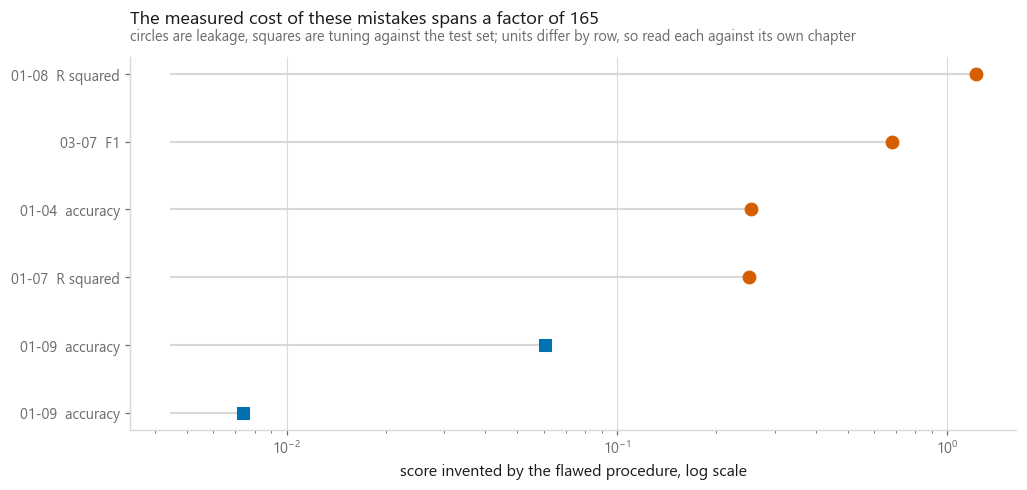

In [3]:
invented = LEDGER[LEDGER["invented"]].sort_values("value").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.4, 4.4))
positions = np.arange(len(invented))
colours = [style.HIGHLIGHT if m == "leaking a fitted step" else style.PALETTE[0]
           for m in invented["mistake"]]
markers = [style.MARKERS[0] if m == "leaking a fitted step" else style.MARKERS[1]
           for m in invented["mistake"]]

for i, (value, colour, marker) in enumerate(zip(invented["value"], colours, markers)):
    ax.hlines(i, invented["value"].min() * 0.6, value, color=style.RULE, lw=1.4)
    ax.scatter(value, i, color=colour, marker=marker, s=70, zorder=3)

ax.set_xscale("log")
ax.set_yticks(positions, [f"{r['chapter']}  {r['units']}" for _, r in invented.iterrows()])
ax.set_xlabel("score invented by the flawed procedure, log scale")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)

spread = invented["value"].max() / invented["value"].min()
style.title(ax,
            f"The measured cost of these mistakes spans a factor of {spread:.0f}",
            "circles are leakage, squares are tuning against the test set; "
            "units differ by row, so read each against its own chapter")

style.save(fig, FIG / "fig-01-the-ledger.png")

The spread is the point of the chart. Treating every one of these as equally
fatal is how people end up fixing the cheap ones and shipping the expensive
ones. [12-03](../03-pipelines/) measures three leaks against each other on one
dataset and finds the same ordering: the steps that read the target are the ones
that cost you.

## 3. Mistake one, demonstrated: no baseline

The first mistake is the one that makes every other number unreadable. A score
without the score of doing nothing beside it cannot be interpreted, and this is
true whether the score looks good or bad.

In [4]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_predict, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_cal, y_cal = datasets.california_housing()
cal_pick = np.random.default_rng(SEED).choice(len(X_cal), 6000, replace=False)
X_cal, y_cal = X_cal.iloc[cal_pick], y_cal.iloc[cal_pick]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cal, y_cal, test_size=0.25,
                                              random_state=SEED)

regression_rows = []
for name, model in [("predict the mean", DummyRegressor(strategy="mean")),
                    ("ridge", Pipeline([("scale", StandardScaler()), ("model", Ridge())])),
                    ("hist boosting", HistGradientBoostingRegressor(random_state=SEED))]:
    model.fit(Xc_tr, yc_tr)
    regression_rows.append({"model": name,
                            "RMSE": root_mean_squared_error(yc_te, model.predict(Xc_te))})

regression = pd.DataFrame(regression_rows)
regression["% of the baseline error removed"] = (
    100 * (1 - regression["RMSE"] / regression.loc[0, "RMSE"]))
print(regression.to_string(index=False, formatters={
    "RMSE": "{:.4f}".format, "% of the baseline error removed": "{:+.1f}".format}))

           model   RMSE % of the baseline error removed
predict the mean 1.1578                            +0.0
           ridge 0.7552                           +34.8
   hist boosting 0.5391                           +53.4


In [5]:
X_bean, y_bean = datasets.dry_bean()
bean_pick = np.random.default_rng(SEED).choice(len(X_bean), 4000, replace=False)
X_bean_s, y_bean_s = X_bean.iloc[bean_pick], y_bean.iloc[bean_pick]

bean_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
classification_rows = []
for name, model in [
        ("always the majority class", DummyClassifier(strategy="most_frequent")),
        ("logistic regression", Pipeline([("scale", StandardScaler()),
                                          ("model", LogisticRegression(max_iter=3000))]))]:
    accuracy = cross_val_score(model, X_bean_s, y_bean_s, cv=bean_cv).mean()
    classification_rows.append({"model": name, "accuracy": accuracy})

classification = pd.DataFrame(classification_rows)
margin = classification.loc[1, "accuracy"] - classification.loc[0, "accuracy"]
majority_share = y_bean_s.value_counts(normalize=True).iloc[0]

print(f"\nseven bean varieties over {len(y_bean_s):,} rows")
print(f"largest class: {y_bean_s.value_counts().index[0]}, {majority_share:.2%} of rows\n")
print(classification.to_string(index=False, float_format="{:.4f}".format))
print(f"\nmargin over the majority class: {margin:+.4f}")


seven bean varieties over 4,000 rows
largest class: DERMASON, 26.17% of rows

                    model  accuracy
always the majority class    0.2617
      logistic regression    0.9238

margin over the majority class: +0.6620


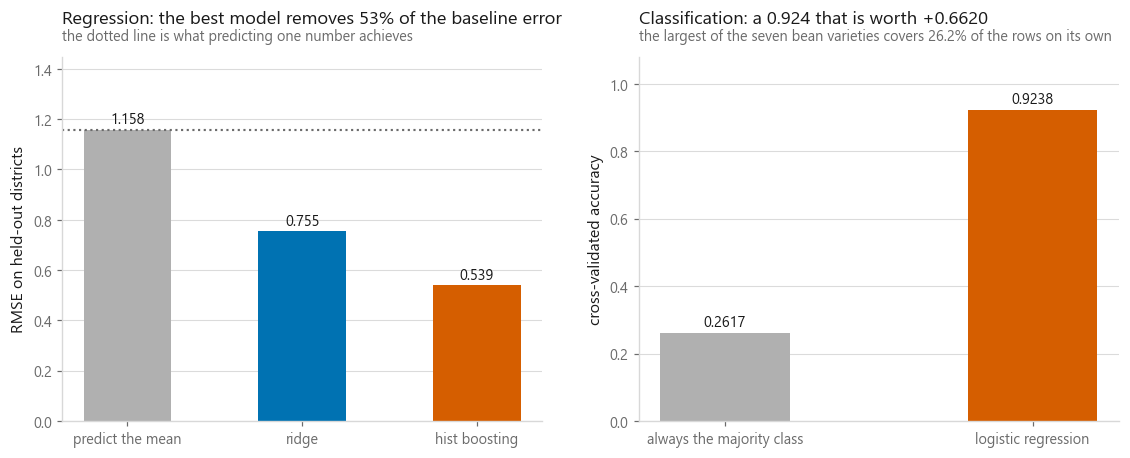

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

bars = axes[0].bar(regression["model"], regression["RMSE"],
                   color=[style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT], width=0.5)
axes[0].set_ylim(0, regression["RMSE"].max() * 1.25)
axes[0].set_ylabel("RMSE on held-out districts")
for bar, value in zip(bars, regression["RMSE"]):
    axes[0].annotate(f"{value:.3f}", (bar.get_x() + bar.get_width() / 2, value),
                     xytext=(0, 4), textcoords="offset points", ha="center",
                     fontsize=9.5, color=style.INK)
axes[0].axhline(regression.loc[0, "RMSE"], color=style.MUTED, ls=":", lw=1.4)
style.title(axes[0],
            f"Regression: the best model removes "
            f"{regression['% of the baseline error removed'].max():.0f}% of the baseline error",
            "the dotted line is what predicting one number achieves")

bars = axes[1].bar(classification["model"], classification["accuracy"],
                   color=[style.NEUTRAL, style.HIGHLIGHT], width=0.42)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel("cross-validated accuracy")
for bar, value in zip(bars, classification["accuracy"]):
    axes[1].annotate(f"{value:.4f}", (bar.get_x() + bar.get_width() / 2, value),
                     xytext=(0, 4), textcoords="offset points", ha="center",
                     fontsize=9.5, color=style.INK)
style.title(axes[1],
            f"Classification: a {classification.loc[1, 'accuracy']:.3f} that is worth "
            f"{margin:+.4f}",
            f"the largest of the seven bean varieties covers "
            f"{majority_share:.1%} of the rows on its own")

style.save(fig, FIG / "fig-02-no-baseline.png")

Both margins here are wide, which is what a healthy result looks like: the model
is doing most of the work rather than inheriting it from the shape of the data.

The reason to print the baseline anyway is that you cannot tell a wide margin
from a narrow one without it, and the narrow case does not announce itself. In
the seven-class problem above, the largest class covers about a quarter of the
rows, so accuracy has room to say something. Make one class rare and that room
disappears, which is section 5.

## 4. Mistake two, demonstrated: one split, no interval

Two models, one train and test split, one number each, and whichever is larger
wins. This is how almost every model comparison in the world is made, and it is
a coin flip more often than anyone expects.

In [7]:
compare_pick = np.random.default_rng(SEED).choice(len(X_bean), 1500, replace=False)
X_cmp, y_cmp = X_bean.iloc[compare_pick], y_bean.iloc[compare_pick]

model_a = Pipeline([("scale", StandardScaler()),
                    ("model", LogisticRegression(max_iter=3000))])
model_b = Pipeline([("scale", StandardScaler()),
                    ("model", RandomForestClassifier(n_estimators=150,
                                                     random_state=SEED, n_jobs=-1))])

N_SPLITS = 40
differences = []
for seed in range(N_SPLITS):
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
        X_cmp, y_cmp, test_size=0.25, random_state=seed, stratify=y_cmp)
    a = model_a.fit(Xs_tr, ys_tr).score(Xs_te, ys_te)
    b = model_b.fit(Xs_tr, ys_tr).score(Xs_te, ys_te)
    differences.append(a - b)

differences = np.array(differences)
print(f"rows in the comparison : {len(X_cmp):,}")
print(f"single splits tried    : {N_SPLITS}\n")
print(f"logistic regression ahead in : {(differences > 0).mean():.1%} of splits")
print(f"mean difference              : {differences.mean():+.4f}")
print(f"standard deviation           : {differences.std(ddof=1):.4f}")
print(f"most flattering split        : {differences.max():+.4f}")
print(f"least flattering split       : {differences.min():+.4f}")
print(f"range across seeds           : {differences.max() - differences.min():.4f}")

rows in the comparison : 1,500
single splits tried    : 40

logistic regression ahead in : 80.0% of splits
mean difference              : +0.0139
standard deviation           : 0.0114
most flattering split        : +0.0400
least flattering split       : -0.0080
range across seeds           : 0.0480


In [8]:
repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEED)
folds_a = cross_val_score(model_a, X_cmp, y_cmp, cv=repeated)
folds_b = cross_val_score(model_b, X_cmp, y_cmp, cv=repeated)
paired_mean, paired_low, paired_high = evaluate.paired_ci(folds_a, folds_b)

print(f"logistic regression, 5-fold x 4 repeats : {folds_a.mean():.4f}")
print(f"random forest, the same folds           : {folds_b.mean():.4f}")
print(f"paired difference                       : {paired_mean:+.4f} "
      f"[{paired_low:+.4f}, {paired_high:+.4f}]")
print(f"interval excludes zero                  : {paired_low > 0 or paired_high < 0}")

logistic regression, 5-fold x 4 repeats : 0.9180
random forest, the same folds           : 0.9055
paired difference                       : +0.0125 [+0.0063, +0.0187]
interval excludes zero                  : True


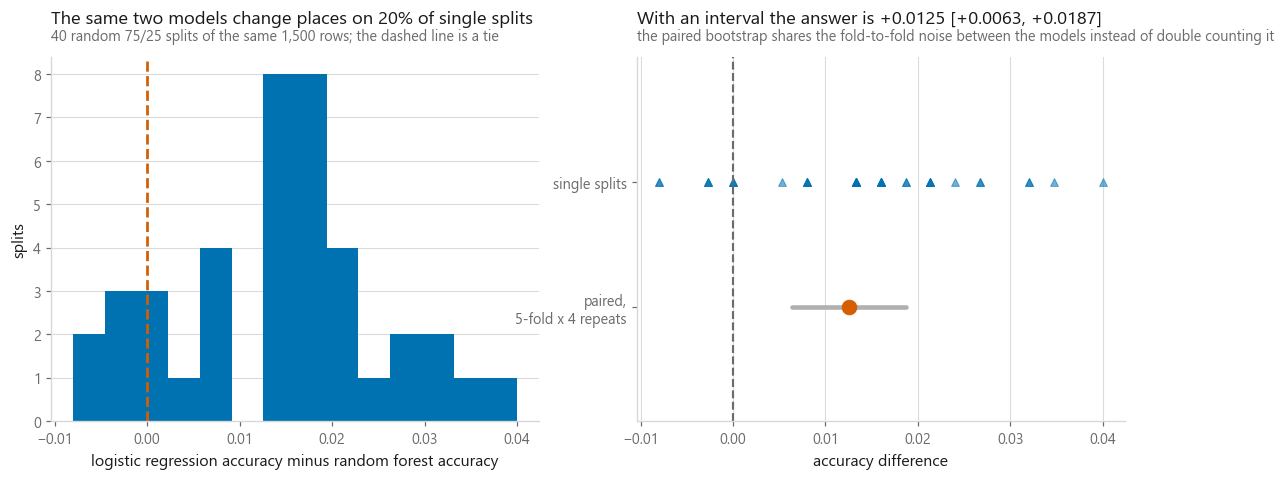

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

axes[0].hist(differences, bins=14, color=style.PALETTE[0])
axes[0].axvline(0, color=style.HIGHLIGHT, ls="--", lw=1.8)
axes[0].set_xlabel("logistic regression accuracy minus random forest accuracy")
axes[0].set_ylabel("splits")
flips = (differences <= 0).mean()
style.title(axes[0],
            f"The same two models change places on {flips:.0%} of single splits",
            f"{N_SPLITS} random 75/25 splits of the same {len(X_cmp):,} rows; "
            f"the dashed line is a tie")

axes[1].plot([paired_low, paired_high], [0, 0], color=style.NEUTRAL, lw=3.0,
             solid_capstyle="round")
axes[1].scatter([paired_mean], [0], color=style.HIGHLIGHT, marker=style.MARKERS[0], s=90,
                zorder=3)
axes[1].scatter(differences, np.full(len(differences), 0.55), color=style.PALETTE[0],
                marker=style.MARKERS[2], s=26, alpha=0.55)
axes[1].axvline(0, color=style.MUTED, ls="--", lw=1.4)
axes[1].set_yticks([0, 0.55], ["paired,\n5-fold x 4 repeats", "single splits"])
axes[1].set_ylim(-0.5, 1.1)
axes[1].set_xlabel("accuracy difference")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
style.title(axes[1],
            f"With an interval the answer is {paired_mean:+.4f} "
            f"[{paired_low:+.4f}, {paired_high:+.4f}]",
            "the paired bootstrap shares the fold-to-fold noise between the models "
            "instead of double counting it")

style.save(fig, FIG / "fig-03-one-split-no-interval.png")

The interval settles it at this sample size, and the honest sentence is longer
than people want it to be: on fifteen hundred bean rows, logistic regression
beats this forest by the printed amount, and a single split would have told you
the opposite in a noticeable share of tries.

[01-04](../../01-foundations/04-cross-validation/) measured the same effect from
the other direction, finding a single split several times more variable than a
cross-validated mean over the same data. `toolkit.evaluate.paired_ci` is four
lines and removes the excuse.

## 5. Mistake three, demonstrated: accuracy on unbalanced classes

The ledger records this one twice from two different chapters. Here is the sweep
neither of them ran: hold the model, the features and the number of positive rows
fixed, and vary only how many negatives are in the room.

In [10]:
from sklearn.metrics import average_precision_score, balanced_accuracy_score

positives = X_bean[y_bean == "SIRA"]
negatives = X_bean[y_bean != "SIRA"]
N_POSITIVE = 120

sweep_rows = []
for rate in [0.50, 0.20, 0.10, 0.05, 0.02]:
    n_negative = int(N_POSITIVE * (1 - rate) / rate)
    if n_negative > len(negatives):
        continue
    frame = pd.concat([positives.sample(N_POSITIVE, random_state=SEED),
                       negatives.sample(n_negative, random_state=SEED)])
    labels = pd.Series([1] * N_POSITIVE + [0] * n_negative, index=frame.index)

    probability = cross_val_predict(
        Pipeline([("scale", StandardScaler()),
                  ("model", LogisticRegression(max_iter=3000))]),
        frame, labels, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
        method="predict_proba")[:, 1]
    predicted = (probability >= 0.5).astype(int)

    sweep_rows.append({
        "positive rate": labels.mean(),
        "rows": len(labels),
        "majority class accuracy": 1 - labels.mean(),
        "model accuracy": (predicted == labels).mean(),
        "margin": (predicted == labels).mean() - (1 - labels.mean()),
        "balanced accuracy": balanced_accuracy_score(labels, predicted),
        "average precision": average_precision_score(labels, probability),
    })

sweep = pd.DataFrame(sweep_rows)
print(sweep.to_string(index=False, formatters={
    "positive rate": "{:.2%}".format, "majority class accuracy": "{:.4f}".format,
    "model accuracy": "{:.4f}".format, "margin": "{:+.4f}".format,
    "balanced accuracy": "{:.4f}".format, "average precision": "{:.4f}".format}))

positive rate  rows majority class accuracy model accuracy  margin balanced accuracy average precision
       50.00%   240                  0.5000         0.8833 +0.3833            0.8833            0.9195
       20.00%   600                  0.8000         0.8733 +0.0733            0.7146            0.8302
       10.00%  1200                  0.9000         0.9000 +0.0000            0.5000            0.7445
        5.00%  2400                  0.9500         0.9500 +0.0000            0.5000            0.6408
        2.00%  6000                  0.9800         0.9800 +0.0000            0.5000            0.3784


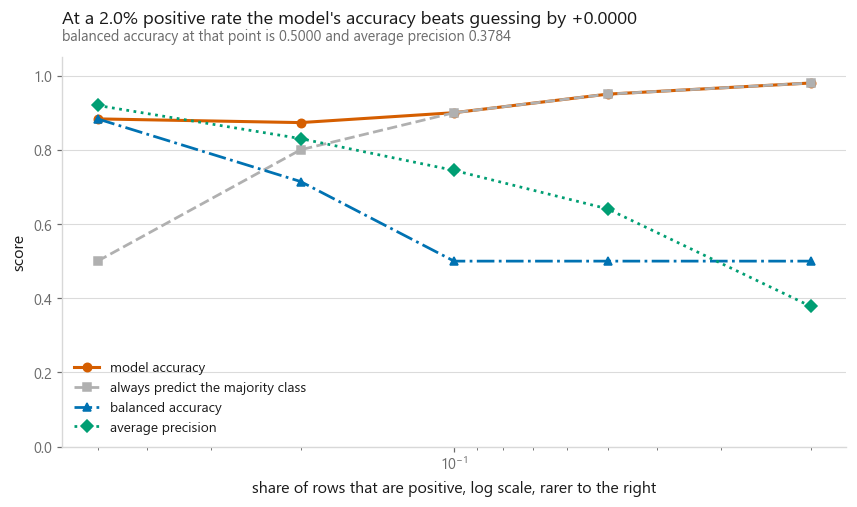

In [11]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(sweep["positive rate"], sweep["model accuracy"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], ls=style.DASHES[0], lw=2.0, label="model accuracy")
ax.plot(sweep["positive rate"], sweep["majority class accuracy"], color=style.NEUTRAL,
        marker=style.MARKERS[1], ls=style.DASHES[1], lw=1.8,
        label="always predict the majority class")
ax.plot(sweep["positive rate"], sweep["balanced accuracy"], color=style.PALETTE[0],
        marker=style.MARKERS[2], ls=style.DASHES[2], lw=1.8, label="balanced accuracy")
ax.plot(sweep["positive rate"], sweep["average precision"], color=style.PALETTE[2],
        marker=style.MARKERS[3], ls=style.DASHES[3], lw=1.8, label="average precision")

ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("share of rows that are positive, log scale, rarer to the right")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=9)

worst = sweep.iloc[-1]
style.title(ax,
            f"At a {worst['positive rate']:.1%} positive rate the model's accuracy "
            f"beats guessing by {worst['margin']:+.4f}",
            f"balanced accuracy at that point is {worst['balanced accuracy']:.4f} and "
            f"average precision {worst['average precision']:.4f}")

style.save(fig, FIG / "fig-04-accuracy-converges-on-the-baseline.png")

Accuracy and the majority-class rate converge, and the two metrics that were
still moving are the two that ignore the pile of true negatives. Read the table
rather than the chart for the exact rows, and note what balanced accuracy is
doing at the bottom of the sweep: it is telling you the model has stopped
predicting the positive class at all, at a threshold of one half, while accuracy
reports a number that would pass a review.

[03-07](../../03-classification/07-imbalanced-classes/) is the chapter about
what to do instead, and its answer is a threshold rather than a resampler.

## 6. Mistake four, demonstrated: a chart title that stopped being true

This one is about the book's own working method, and it is the reason every
title in these notebooks is an f-string computed when the figure is drawn.

Here is the sequence, played out. I compare two models on a sample of the Dry
Bean data, find a winner, and write the finding into the chart title the way
anyone would. Then the analysis grows, as analyses do, and I run it on the full
dataset. The chart is regenerated. The title is not, because it is a string.

In [12]:
cv_flip = StratifiedKFold(5, shuffle=True, random_state=SEED)

flip_rows = []
for n in [1500, len(X_bean)]:
    idx = np.random.default_rng(SEED).choice(len(X_bean), n, replace=False)
    Xn, yn = X_bean.iloc[idx], y_bean.iloc[idx]
    a = cross_val_score(model_a, Xn, yn, cv=cv_flip).mean()
    b = cross_val_score(model_b, Xn, yn, cv=cv_flip).mean()
    flip_rows.append({"rows": n, "logistic regression": a, "random forest": b,
                      "winner": "logistic regression" if a > b else "random forest",
                      "margin": abs(a - b)})

flip = pd.DataFrame(flip_rows)
print(flip.to_string(index=False, formatters={
    "logistic regression": "{:.4f}".format, "random forest": "{:.4f}".format,
    "margin": "{:.4f}".format}))

first_run, second_run = flip.iloc[0], flip.iloc[1]
STALE_TITLE = f"Logistic regression beats the forest by {first_run['margin']:.4f}"
print(f"\nthe title I wrote after the first run : {STALE_TITLE!r}")
print(f"is it still true on the full dataset  : "
      f"{second_run['winner'] == 'logistic regression'}")

 rows logistic regression random forest              winner margin
 1500              0.9153        0.9000 logistic regression 0.0153
13611              0.9237        0.9245       random forest 0.0008

the title I wrote after the first run : 'Logistic regression beats the forest by 0.0153'
is it still true on the full dataset  : False


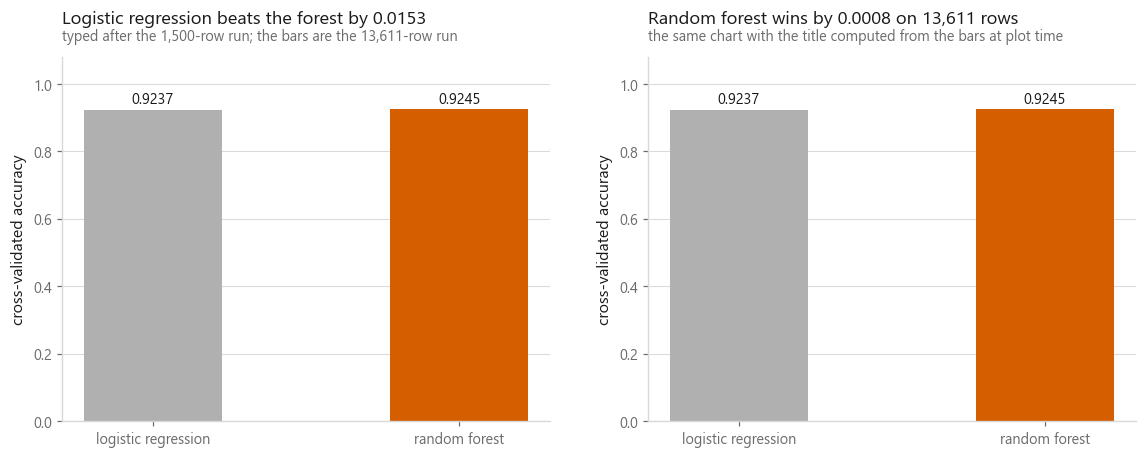

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

for ax, row, headline, subtitle in [
        (axes[0], second_run, STALE_TITLE,
         f"typed after the {first_run['rows']:,}-row run; the bars are the "
         f"{second_run['rows']:,}-row run"),
        (axes[1], second_run,
         f"{second_run['winner'].capitalize()} wins by {second_run['margin']:.4f} "
         f"on {second_run['rows']:,} rows",
         "the same chart with the title computed from the bars at plot time")]:
    values = [row["logistic regression"], row["random forest"]]
    leader = int(np.argmax(values))
    bars = ax.bar(["logistic regression", "random forest"], values,
                  color=[style.HIGHLIGHT if i == leader else style.NEUTRAL
                         for i in range(2)], width=0.45)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("cross-validated accuracy")
    for bar, value in zip(bars, values):
        ax.annotate(f"{value:.4f}", (bar.get_x() + bar.get_width() / 2, value),
                    xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=9.5, color=style.INK)
    style.title(ax, headline, subtitle)

style.save(fig, FIG / "fig-05-a-title-that-stopped-being-true.png")

Both panels are drawn from the same numbers. The left one carries a sentence
that was true when it was written and no longer matches its own bars, and
nothing in the pipeline that produced it would ever notice. The printed table
above says which way the comparison moved.

The flip is not an artefact either. It is the ordinary way model comparisons
behave: a linear model wins when rows are few and loses when there are enough
rows for a flexible model to pin its structure down, which is the thread running
through [the scoreboard](../01-the-scoreboard/) and
[01-03](../../01-foundations/03-overfitting-and-underfitting/).

The rule that comes out of this is small and it has saved me repeatedly:
**a title that states a finding must be computed from the data it sits on.**
Same for a number in a paragraph. If it cannot be regenerated, it will eventually
be wrong, and it will be wrong quietly.

## 7. The five that were not demonstrated here

### Leaking a fitted step across the fold boundary

The most expensive mistake in the ledger, and the whole subject of
[12-03](../03-pipelines/), which measures three leaks against each other and
finds that the ones reading the target cost orders of magnitude more than the
ones that do not. The four supporting rows come from
[01-04](../../01-foundations/04-cross-validation/),
[01-07](../../01-foundations/07-feature-scaling-and-encoding/),
[01-08](../../01-foundations/08-missing-data/) and
[03-07](../../03-classification/07-imbalanced-classes/). The fix is one object,
and it is free.

### Tuning against the test set

[01-02](../../01-foundations/02-train-validation-test/) tunes against a test set
the way people actually do and tracks the drift from honest performance after
every look. [01-09](../../01-foundations/09-hyperparameter-tuning/) reports a
real search against nested cross-validation and simulates the pure version, where
every candidate is truly identical and the reported winner is inflated anyway.
The mechanism is the maximum of noisy numbers, so no amount of care inside the
models prevents it.

### Reading feature importance as causation

[12-02](../02-interpreting-models/) measures three separate failures of the same
reflex. Impurity importance rewards columns with many distinct values, and gave a
planted noise column most of the credit of a real feature. Two correlated columns
each report as disposable because permuting one leaves the other to answer with.
And permutation, partial dependence, LIME and Shapley all evaluate the model on
rows that could not exist, once the features depend on each other. Every one of
them describes the model. None of them describes the world.

### Reporting variance without the signal

[11-07](../../11-reinforcement-learning/07-policy-gradients/) has the cleanest
example in the book. Lowering the discount cut the gradient variance by more than
a hundredfold, which is the standard argument for doing it, and made the
noise-to-signal ratio ten times worse over the same range, because it shrank the
signal faster than the noise. A variance number with nothing beside it points the
wrong way, and the same trap catches anyone reporting a standard deviation, a
confidence width or a loss without the quantity it is a fraction of.

### Believing a training curve is a policy

[07-06](../06-regularisation/) recorded a validation loss that bottomed out nine
epochs before the best test accuracy arrived, so the curve people stop on and
the outcome they want disagreed. The same chapter measures the
harsher version: evaluating without `model.eval()` reports an accuracy that
depends on the evaluation batch size, a parameter that should not affect anything,
and the error at a small batch was larger than the gap between any two methods in
the chapter. A curve is a measurement of a run, under the conditions of that run.
It is not a decision rule and it is not transferable.

## 8. The checklist

Printed rather than written out, so it is one object you can copy.

In [14]:
CHECKLIST = pd.DataFrame([
    ("before modelling", "look at the target's distribution and count what is capped, missing or duplicated", "01-01"),
    ("before modelling", "decide what a held-out row means: random, grouped, or later in time", "01-02"),
    ("first model", "fit a DummyRegressor or DummyClassifier and write the number down", "01-01"),
    ("every experiment", "everything with a fit method goes inside the Pipeline", "12-03"),
    ("every comparison", "repeated folds and a paired interval, never one split", "01-04"),
    ("classification", "print the majority-class rate next to accuracy, or use another metric", "01-05"),
    ("tuning", "nested cross-validation or a test set touched once. Never best_score_", "01-09"),
    ("interpretation", "permutation importance on held-out rows, and no causal language", "12-02"),
    ("any variance claim", "report the signal beside it", "11-07"),
    ("any chart", "the title is computed from the data at plot time", "12-05"),
    ("shipping", "save the pipeline, with feature names and one golden input", "12-04"),
], columns=["when", "do this", "measured in"])

print(CHECKLIST.to_string(index=False))

              when                                                                           do this measured in
  before modelling look at the target's distribution and count what is capped, missing or duplicated       01-01
  before modelling               decide what a held-out row means: random, grouped, or later in time       01-02
       first model                 fit a DummyRegressor or DummyClassifier and write the number down       01-01
  every experiment                             everything with a fit method goes inside the Pipeline       12-03
  every comparison                             repeated folds and a paired interval, never one split       01-04
    classification             print the majority-class rate next to accuracy, or use another metric       01-05
            tuning             nested cross-validation or a test set touched once. Never best_score_       01-09
    interpretation                   permutation importance on held-out rows, and no causal lang

## 9. The one habit underneath all of them

Every mistake in this chapter has the same shape. A number was produced by a
procedure, and the number was read as if it had been produced by a different,
better procedure.

The accuracy was real, and it was the accuracy of a model that had seen its test
set. The importance was real, and it was the importance of a column inside a
model rather than a cause in the world. The improvement was real, and it was the
improvement of the best of two hundred attempts rather than of the method. In
none of these cases was the arithmetic wrong.

So the habit that prevents all nine is one question, asked of every number before
it leaves the notebook: **what exactly was measured, and what would it have said
if there were nothing there?** The first half catches the leaks and the causal
readings. The second half is the baseline, which is where this book started.

That is the end of it. Eighty-six notebooks, five datasets, and one idea repeated
until it is boring: measure the thing, measure what doing nothing achieves, and
report the gap. Everything else is technique.

## Cheat sheet

| | |
|---|---|
| **Most expensive** | Leaking a fitted step. Measured in the ledger above at more than a full point of R squared in one chapter |
| **Most common** | No baseline. Costs nothing to fix and makes every other number readable |
| **Hardest to see** | Tuning against the test set. The model is fine, the number is not, and nothing looks wrong until production |
| **Most misread** | Feature importance. It describes the model, and people quote it as if it described the world |
| **Sneakiest** | A stale chart title or a hardcoded number in prose. Regenerate or delete |
| **The fix for most of them** | `Pipeline`, a `Dummy` estimator, repeated folds, and a paired interval |
| **The question** | What was measured, and what would this say if there were nothing there |
| **Where to go next** | [The scoreboard](../01-the-scoreboard/) for how the methods actually compare, then pick a dataset of your own and run this checklist against it |

## What to remember

1. The mistakes are not equally expensive. The ledger spans a wide range, and
   treating them as one undifferentiated pile is how people fix the cheap ones.
2. Leaks that read the target cost the most. Leaks that only read features are
   real and small.
3. Tuning against a test set does not produce a worse model. It produces a wrong
   number, which is harder to catch.
4. Accuracy converges on the majority-class rate as the positive class gets
   rarer, and the sweep in section 5 shows a model that has stopped predicting
   the positive class while accuracy still looks respectable.
5. A single train and test split changed the winner between two models often
   enough here to be worth nobody's confidence. Use repeated folds and a paired
   interval.
6. Which model wins is a property of the dataset and its size, not a ranking of
   algorithms. The same two models swapped places between a sample and the full
   file.
7. A finding written as a string will eventually contradict the chart it sits on.
   Compute titles from the data.
8. Every one of these is one question away: what was measured, and what would it
   have said if there were nothing there.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Back to [Part 12](../) · [the curriculum](../../CURRICULUM.md) ·
[the book](../../README.md)

`#MachineLearning` `#DataLeakage` `#ModelEvaluation` `#DataScience`
`#ScikitLearn` `#Python` `#MLTutorial` `#LearnMachineLearning` `#Baseline` `#AI`